# Assignment 3: Neural Networks for Quantum State Tomography

In this assignment you will train a neural network to fit the distribution of a quantum state from few measurements of it. Even though this problem has applications in physics, for the purpose of this exercise we will mainly consider it as a regression problem, without concerning us with the physics behind it.

> ⚠️ As usual, we will execute your notebook again when grade you. Please, make sure that it takes no longer than 15min (on google colab) to run from top to bottom. You should be able to solve the exercises without GPU acceleration, but feel free to add it if you want. Comment out code used for exploration where we ask you.


## Introducing the problem: Quantum State Tomography

We are given a dataset with $N$ samples $\{x_i,y_i \}_{i = 1, ..., N}$ where $x_i = \{0,1\}^{\mathtt{n\_spins}}$ is a binary string of length $\mathtt{n\_spins}$ and $y_i \in (0,1]$ is a  number. We have our regression problem.

But where is the data from? We are considering the case where the $x_i$ are the the possible outcomes of a measurement of a quantum state $\Psi$ and $y_i$ is the probability of observing outcome $x_i$.
Our goal is to train a neural network $f_\theta(x) = \hat{y}$ that approximates the original probability distribution. Specifically, for the set of possible outcomes $\{x_i\}$, the model should return a vector of probabilities corresponding to each outcome.


## Exercise 1 (10 pts): A fully connected network

For the purpose of this exercise, we give you a function that samples $N$ measurements from a quantum state along with their probabilities.

In [1]:
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

def get_data(n_spins):

    # Loads the data available in the .txt files we made available to you.

    if n_spins not in [8,12,16]:
        raise ValueError(f"The data for {n_spins} is not available.")

    numbers = [bin(i)[2:].zfill(n_spins) for i in range(2**n_spins)]
    xs = [[int(char) for char in string] for string in numbers]
    X = np.array(xs)

    Wstate = np.loadtxt(f"target_state_{n_spins}.txt")
    Y = np.abs(Wstate)**2

    # shuffle
    idx = np.random.permutation(range(len(Y)))

    return X[idx], Y[idx]

a) Load the data for `n_spins=16` and visualize the labels as a histogram. Visualize both `y` and `log(y)` in different plots. Which representation is more informative?

*Answer:* Applying the logarithm is more informative, because the spaces between the values do not scale uniformly, but are in a dynamic range down to $10^{-6}$.

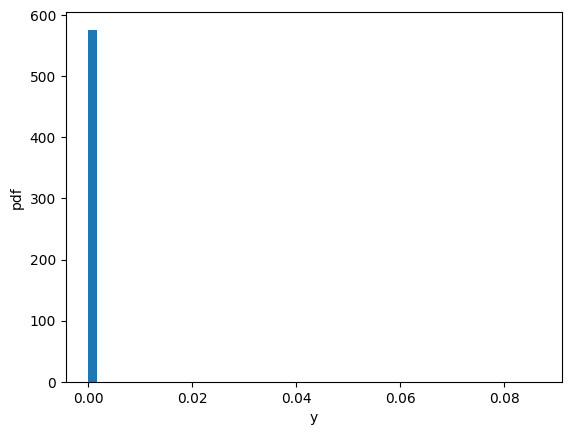

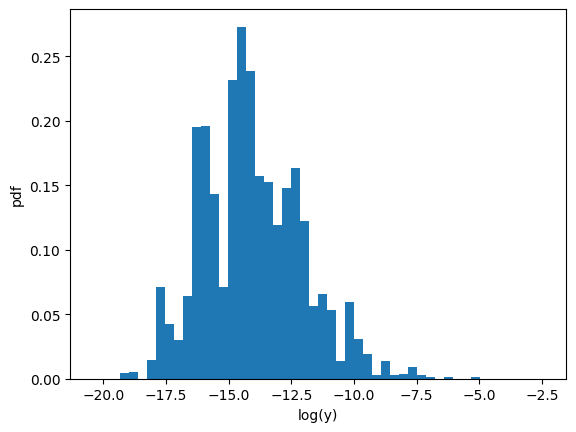

In [2]:
X, Y = get_data(n_spins=16)

plt.hist(Y,bins=50, density=True)
plt.xlabel('y')
plt.ylabel('pdf')
plt.show()

plt.hist(np.log(Y),bins=50, density=True)
plt.xlabel('log(y)')
plt.ylabel('pdf');

b) We want to continue working with this datasets in two different forms, either without or with the log-transform of the labels : $\{x_i,y_i\}$ or $\{x_i,log(y_i)\}$. Then we want to train neural networks on this data using SGD.

Complete the function `get_loaders`. Set `n_spins=12` and apply the log transform according to the normalize variable. Create a test, train and validation dataset using `TensorDataset`, the split should be done at (40%,20%,40%) of the original data. To prepare for training, wrap the new datasets in torch `DataLoaders` as you have seen in previous exercises. For training data loader, use a batch size 32 and use shuffling, for test and validation data loaders use the full batch and don't shuffle.

In [3]:
n_spins = 12
X, Y = get_data(n_spins=n_spins)


def get_loaders(X, Y, normalize_log = True):
  X_tensor = torch.tensor(X, dtype=torch.float32)
  Y_tensor = torch.tensor(np.log(Y) if normalize_log else Y, dtype=torch.float32).unsqueeze(1)

  n_samples = X_tensor.shape[0]
  train_split = int(n_samples * 0.2)
  val_split = int(n_samples * 0.6)
  test_split = int(n_samples * 1.0)

  X_train, X_val, X_test = X_tensor[:train_split], X_tensor[train_split:val_split], X_tensor[val_split:test_split]
  Y_train, Y_val, Y_test = Y_tensor[:train_split], Y_tensor[train_split:val_split], Y_tensor[val_split:test_split]

  train_dataset = TensorDataset(X_train, Y_train)
  val_dataset = TensorDataset(X_val, Y_val)
  test_dataset = TensorDataset(X_test, Y_test)

  batch_size = 32

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  val_loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)
  test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)
  return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_loaders(X, Y)

c) Define a general function `train` as given below that takes the test and train loaders, a learning rate and a model, a number of epochs and optionally a boolean `logging`equal to `True` by default and returns the train and test losses for every epoch, and the best test loss achieved overall.

You are supposed to run SGD with the MSE loss. Print the progress of your training by printing the losses every epoch, if `logging==True`.

- I) In the course of your code you will use the line `optimizer.zero_grad()`. Explain briefly what happens when you call this function, and when and why you need to call it.

- II)  Explain why we previously needed to activate the batches and shuffling for the training dataloader.

- III) When a dataloader is used several times for several epochs, is the data shuffled in the same order every time?

*`Answers:`*

- I) PyTorch uses automatic differentiation and it builds a computational graph of all the operations and how they relate each other for parameters stored in the neural network modules, i.e. the tensors. When we call loss.backwards(), the gradients of tensors in the computational graph that lead to this calculation are computed with respect to the loss, specifically in the .grad parameter that lives at the tensor variables themselves. The way this is implemented in pytorch, gradients add up in conseqent backwards passes, i.e. when calling loss.backwards() twice. By calling optimizer.zero_grad() we set all the gradients to zero (None) that are references by the optimzer.

- II) Shuffeling the data avoids periodicity in the gradients. Batches allow us to use stochstic gradient descent and as approximations to the true gradient alleiviate some of the computational burden. In addition, the stochastisty may help to espace local minima where GD might get stalled.

- III) No, the way pytorch implements it, it shuffles it randomly every time (unless you set a random seed).

In [4]:
def train(train_loader, test_loader, lr, model, n_epochs, logging=True):

    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    test_losses = []
    train_losses = []
    for epoch in tqdm(range(n_epochs)):

        train_loss = 0.0

        for batch_idx, (X_batch, Y_batch) in enumerate(train_loader):

            predictions = model(X_batch)
            loss = criterion(predictions, Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        test_loss = 0.0
        with torch.no_grad():
            for X_batch, Y_batch in test_loader:
                predictions = model(X_batch)
                test_loss += criterion(predictions, Y_batch).item()

        test_loss /= len(test_loader)

        test_losses.append(test_loss)
        train_losses.append(train_loss)

        if logging:
            print(f"Epoch {epoch + 1}/{n_epochs}, Train Loss: {train_loss:.8f}, Test Loss: {test_loss:.8f}")

    best_test_loss = min(test_losses)

    return train_losses, test_losses, best_test_loss

d) Test your function by training a 1 hidden layer fully connected network with ReLU activations. You will choose the hyperparameters: `n_epochs` to train and the `learning rate`. You can keep the number of `hidden_neurons=16` fixed for the moment. Hint: You should not need to use more than 2000 epochs in your explorations...

Write the code to train and visualize the test and train losses with a log-sacle on the y-axis.
It is now your turn to play.

Choose `lr=0.1`, `n_epochs=100` and `hidden_neurons=16`. Train 10 models with these hyperparameters and observe their learning curves. We would expect the learning curves of the 10 different models to be different because every time you define a new model, the weights are initialized randomly and the SGD optimizer will go over the batches in a different order.

Describe what differences and similarities you observe. How could you change (some of) the hyperparameters so that the runs are more similar, i.e. the loss curve is less strongly dependent on the initialization?

> ⚠️ Once you are ready to answer the question, leave the code you used for your explorations and the learning curves you produced, but comment it so we don't have to run it again. This hold only for this question

*`Answer:`* All of the 10 models exhibit quite different behaviours beyond generally decreasing the loss. The train and test losses, and the best achieved performance depend significantly on the initial conditions. The train and test losses are rather "spiky" and unstable.
Lowering the training rate, increasing the batch size and increasing the number of epochs could all lead to a more stable and consistent loss behaviour, irregardless of the initialization.

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

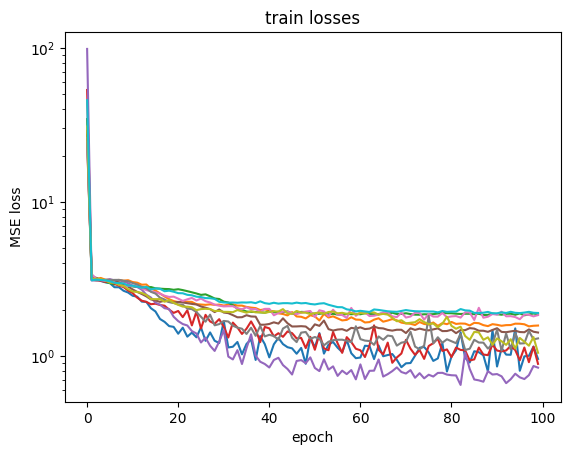

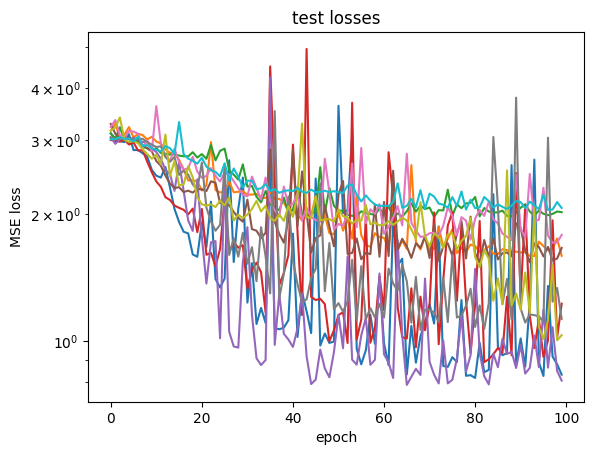

In [5]:
hidden_size = 16
trains = []
tests = []
for _ in range(10):
    model = nn.Sequential(
        nn.Linear(n_spins, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, 1)
    )

    train_losses, test_losses, best_test_loss = train(train_loader, test_loader, lr=0.1, model=model, n_epochs=100,logging=False)

    trains.append(train_losses)
    tests.append(test_losses)

for t in trains:
    plt.plot(t)
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('train losses')
plt.show()

for t in tests:
    plt.plot(t)
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('test losses')
plt.show()

e) Choose some parameters that reliably give you good models even if you restart the training . If you get a test loss around 0.01 you can stop training.

*`Answer:`* See the good parameters below, that regularly end up in a very low loss.

  0%|          | 0/2000 [00:00<?, ?it/s]

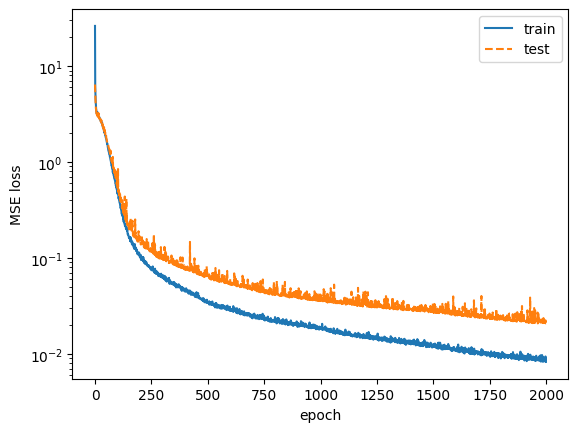

In [6]:
model = nn.Sequential(
        nn.Linear(n_spins, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, 1)
    )

train_losses, test_losses, best_test_loss = train(train_loader, test_loader, lr=0.01, model=model, n_epochs=2000,logging=False)
plt.plot(train_losses, label='train')
plt.plot(test_losses, label='test', linestyle='--')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.show()

f) For the previous model that you liked, plot the histogram of the distribution again with the log transform, for test data. Also plot the predicted and ground truth values against each other. Are you satisfied with the match?

*`Answer:`* Yes, the match is quite satifying.

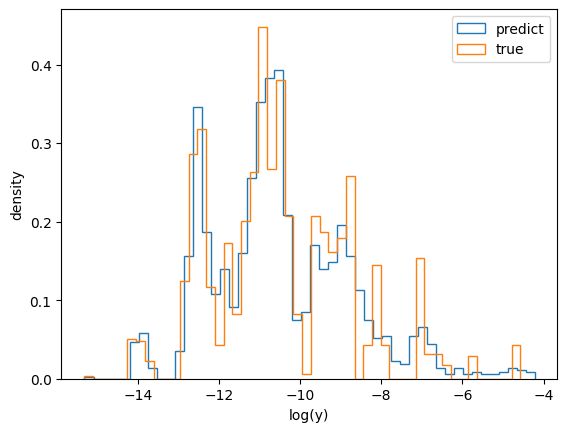

Text(0, 0.5, 'log(y_predict)')

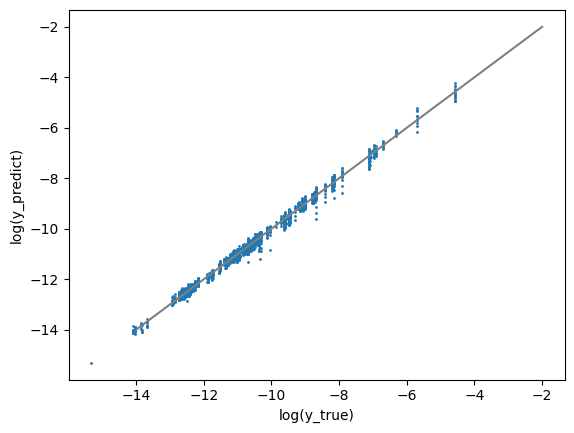

In [7]:
X_test, y_test = next(iter(test_loader))
y_pred = model(X_test).detach().numpy()

plt.hist(y_pred,bins=50,histtype='step',density=True,label='predict')
plt.hist(y_test.squeeze(1).numpy(),bins=50,histtype='step',density=True,label='true')
plt.xlabel('log(y)')
plt.legend()
plt.ylabel('density')
plt.show()

y_pred = model(X_test).detach().cpu().numpy()
plt.scatter(y_test.squeeze(1).numpy(), y_pred,s=1)
plt.plot([-14,-2],[-14,-2],color='grey')
plt.xlabel('log(y_true)')
plt.ylabel('log(y_predict)')

## Exercise 2 (6 pts): Exploring alternative architectures  and losses

You have found a model that works! But can you make it more efficient?

a) A linear regression model would for example use fewer parameters. Try the model and based on your experiment argue that it is less suitable for this task than the fully connected neural network.

*`Answer:`* As we see below with the linear regression (LR) we only achieve a much higher loss compared to what we had before with the neural network with one hidden layer (3 orders of magnitude!). This indicates that the LR is less suitable, and the data likely contains interactions between spins that are non-linear and can therefore not be captured by the LR.

  0%|          | 0/400 [00:00<?, ?it/s]

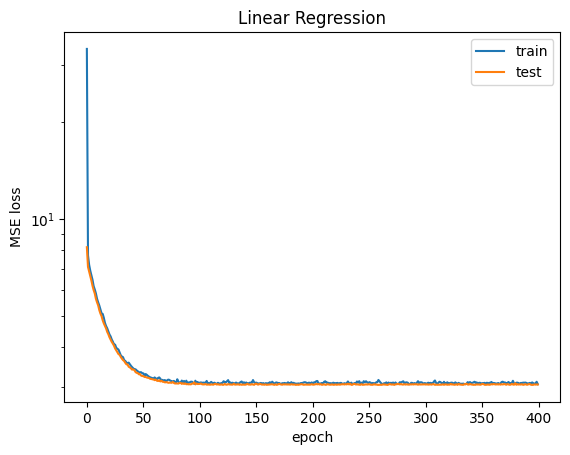

In [8]:
model = nn.Linear(n_spins, 1)
train_losses, test_losses, best_test_loss = train(train_loader, test_loader, lr=0.01, model=model, n_epochs=400, logging=False)
plt.plot(train_losses, label='train')
plt.plot(test_losses, label='test')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.title('Linear Regression')
plt.show()

b) If a linear regression does not work, maybe you can fine-tune the number of hidden neurons. Select 5 different values of the hidden neurons `[2,8,16,32,64]` and train those models. Use at max 500 epochs to train every model and a learning rate of 0.01. In reality you would optimize the learning rate for each architecture and you can still do so if you wish, but to save you time we do not require this. After the models are trained, select the best one based on the best test loss.

Estimate the loss you can expect on the model that you just selected on a fresh data sample, that has not been seen in the process of selecting this model.

*`Answer:`* We observe that the model with 16 hidden neurons obtains the best test loss, even though there is slight variability between the runs, so sometimes 32 and 64 hidden neurons give good results. In order to estimate how our selected model is doing on new data, we cannot use the test data used in the selection process. Since the validation loader contains data that has not been used in the process of generating data, we use this one instead, as it gives us an unbiased estimate of the generalization error.

  0%|          | 0/500 [00:00<?, ?it/s]

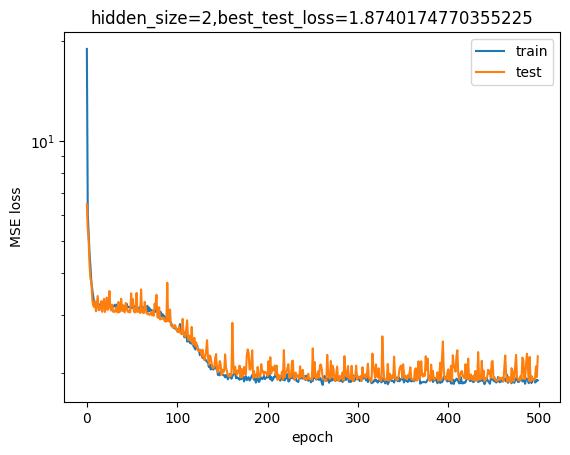

  0%|          | 0/500 [00:00<?, ?it/s]

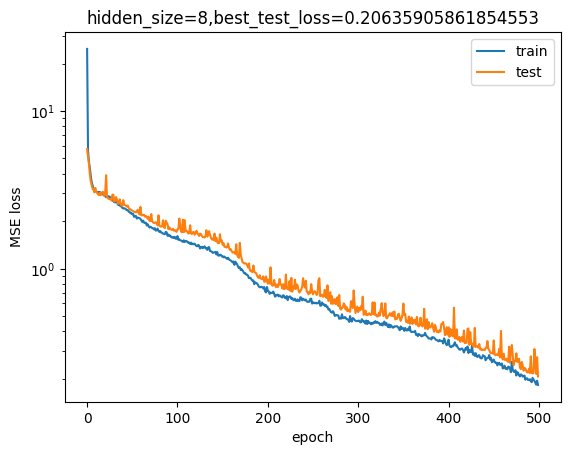

  0%|          | 0/500 [00:00<?, ?it/s]

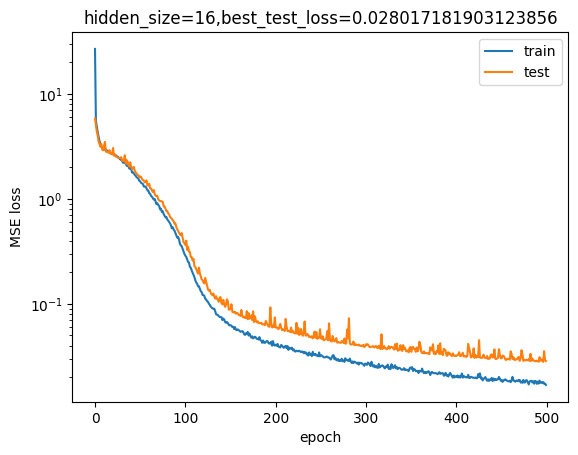

  0%|          | 0/500 [00:00<?, ?it/s]

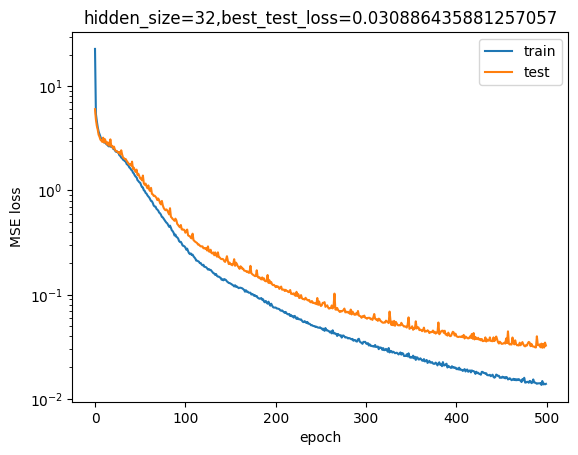

  0%|          | 0/500 [00:00<?, ?it/s]

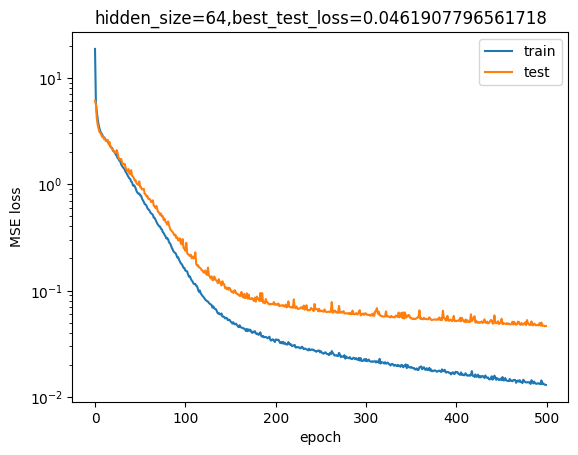

In [9]:
models = []
hidden_neurons = [2,8,16,32,64]
for hidden_size in hidden_neurons:
    model = nn.Sequential(
        nn.Linear(n_spins, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, 1)
    )
    train_losses, test_losses, best_test_loss = train(train_loader, test_loader, lr=0.01, model=model, n_epochs=500, logging=False)
    plt.plot(train_losses, label='train')
    plt.plot(test_losses, label='test')
    plt.yscale('log')
    plt.xlabel('epoch')
    plt.ylabel('MSE loss')
    plt.legend()
    plt.title(f'{hidden_size=},{best_test_loss=}')
    plt.show()
    models.append(model)

In [10]:
model = models[2] # we select the model with 16 hidden units

criterion = nn.MSELoss()
val_loss = 0.0
with torch.no_grad():
    for X_batch, Y_batch in val_loader:
        predictions = model(X_batch)
        val_loss += criterion(predictions, Y_batch).item()

val_loss /= len(val_loader)
print("The estimated loss on fresh data is: ", val_loss)

The estimated loss on fresh data is:  0.025620905682444572


c) Now you want to see what difference the log transformation we applied at the very beginning makes. Train a model on the plain data and compare the models prediction again both via the histogram of y-values and the scatterplot between the predicted and true y, in the log transform. What did the non-log transformed model learn and why?

*`Answer:`* Even though the loss is much lower then for the model with the log-transform, this is meaningless, as the data that is to be predicted is in different dynamic ranges for both models. In fact, looking at the predictions themselvs the model without the log transform does much worse, it gets the approximate scale correclty but not the small variations in the data. This is because in the MSE loss, the squared distances are influencing the final value of the loss. For our dataset this means that the small variations in $10^{-6}$ for values close to zero are not taken into account and are not being predicted. Likewise, it is more important that larger values, outliers, closer to one are predicted accuractely. Since these outliers are balanced by a majority of values lying extremely close to one the outliers effect just shifts the mean prediction slightly upwards, resulting in the prediction we observe. In constrast, the log transform can be thought of a loss function which aims at getting the ratios between samples correct. See this example for a single data point:
$$ \mathcal l(y^*,\hat{y}) = (\log(y^*) - \log(\hat{y}))^2 = \log(y^*/\hat{y})^2 $$
This loss is minimized when the ratio of the two values is close to one, which is making it more evident why the log-transformed data is getting the matches correctly over the complete dynamic range.

  0%|          | 0/100 [00:00<?, ?it/s]

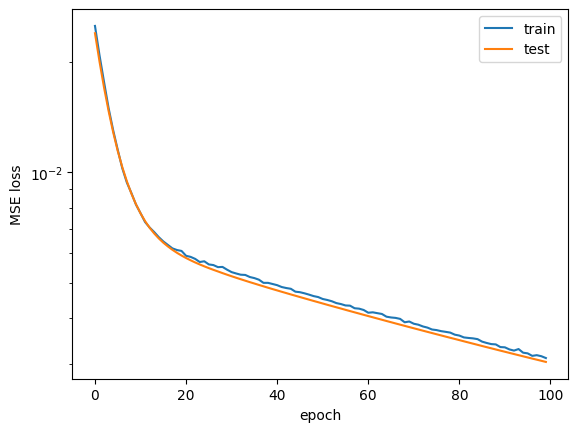

In [11]:
model = nn.Sequential(
        nn.Linear(n_spins, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )

plain_train_loader, plain_val_loader, plain_test_loader = get_loaders(X, Y, normalize_log=False)

train_losses, test_losses, best_test_loss = train(plain_train_loader, plain_test_loader, lr=0.001, model=model, n_epochs=100, logging=False)
plt.plot(train_losses, label='train')
plt.plot(test_losses, label='test')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.show()

<ipython-input-12-4c080e3f67d9>:4: RuntimeWarning: invalid value encountered in log
  plt.hist(np.log(y_pred),bins=50,histtype='step',density=True,label='predict')


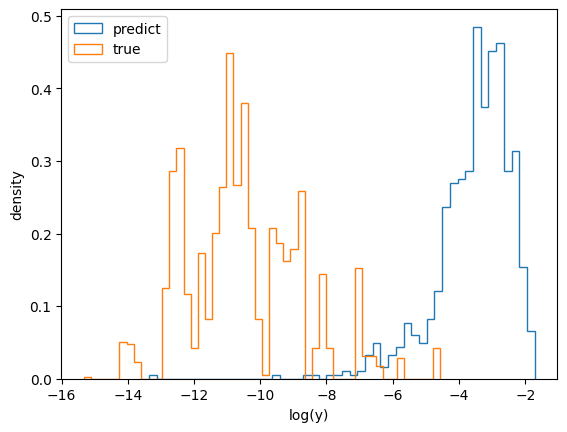

<ipython-input-12-4c080e3f67d9>:12: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(y_test.squeeze(1).numpy()),np.log(y_pred),s=10)


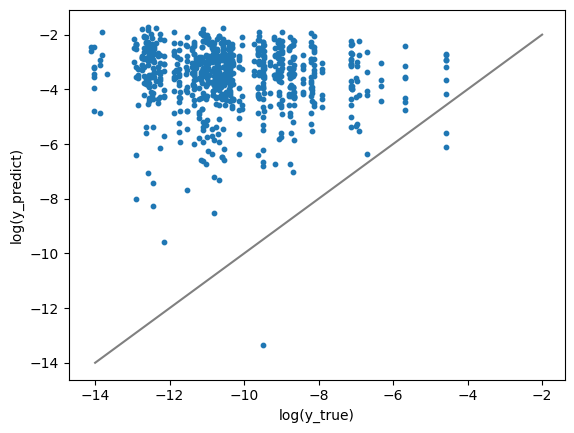

Text(0, 0.5, 'y_predict')

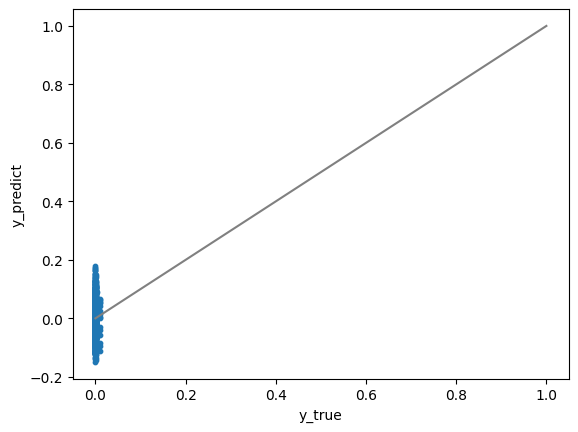

In [12]:
X_test, y_test = next(iter(plain_test_loader))
y_pred = model(X_test).detach().numpy()

plt.hist(np.log(y_pred),bins=50,histtype='step',density=True,label='predict')
plt.hist(np.log(y_test.squeeze(1).numpy()),bins=50,histtype='step',density=True,label='true')
plt.xlabel('log(y)')
plt.legend()
plt.ylabel('density')
plt.show()

y_pred = model(X_test).detach().cpu().numpy()
plt.scatter(np.log(y_test.squeeze(1).numpy()),np.log(y_pred),s=10)
plt.plot([-14,-2],[-14,-2],color='grey')
plt.xlabel('log(y_true)')
plt.ylabel('log(y_predict)')
plt.show()

plt.scatter(y_test.squeeze(1).numpy(),y_pred,s=10)
plt.plot([0,1],[0,1],color='grey')
plt.xlabel('y_true')
plt.ylabel('y_predict')